<a href="https://colab.research.google.com/github/Shashank-Karanam/1BM23CS061/blob/main/1BM23CS312_Lab_11_K_Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K Means Clustering

Write Python code to implement the following. Consider dataset files as “iris.csv”

1. Build a K-Means Clustering algorithm to cluster IRIS flower dataset

2. Use iris flower dataset to form clusters of flowers using petal width and length features. Drop other two features for simplicity.

3. Figure out if any preprocessing such as scaling would help here

4. Draw elbow plot and from that figure out optimal value of k

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv('iris.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
X = df[['petal_length', 'petal_width']]
X.head()

,petal_length,petal_width
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


In [ ]:
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
#Elbow Method
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

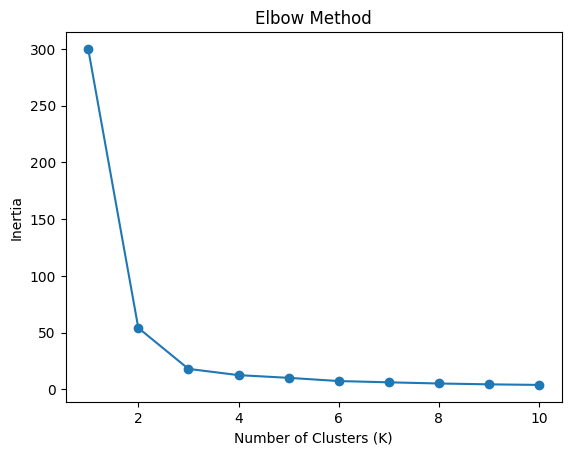

In [ ]:
# Plot Elbow Graph
plt.figure()
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,Cluster
0,5.1,3.5,1.4,0.2,Iris-setosa,1
1,4.9,3.0,1.4,0.2,Iris-setosa,1
2,4.7,3.2,1.3,0.2,Iris-setosa,1
3,4.6,3.1,1.5,0.2,Iris-setosa,1
4,5.0,3.6,1.4,0.2,Iris-setosa,1


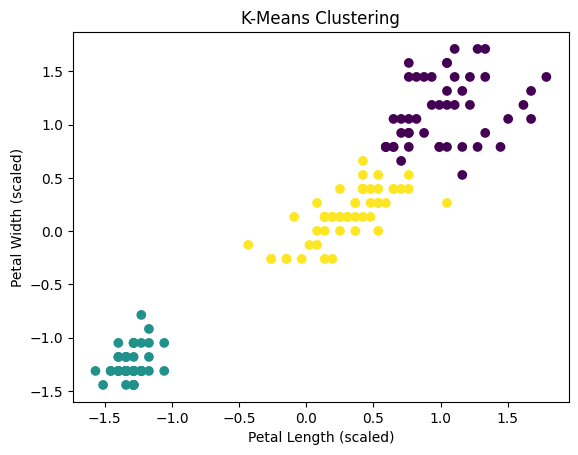

In [ ]:
plt.figure()

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.title("K-Means Clustering")

plt.show()

In [ ]:
cluster_table = df['Cluster'].value_counts().reset_index()
cluster_table.columns = ['Cluster', 'Number of Points']
cluster_table = cluster_table.sort_values(by='Cluster')

cluster_table

,Cluster,Number of Points
2,0,48
1,1,50
0,2,52
